In [1]:
import xarray as xr

bathy = xr.open_dataset("inputs/bathymetry_ISLAND_lonlat.nc")
bathy

<xarray.Dataset> Size: 4kB
Dimensions:    (lon: 36, lat: 23)
Coordinates:
  * lon        (lon) float64 288B -3.628 -3.625 -3.622 ... -3.53 -3.527 -3.524
  * lat        (lat) float64 184B 43.55 43.55 43.54 43.54 ... 43.49 43.49 43.48
Data variables:
    elevation  (lat, lon) float32 3kB ...

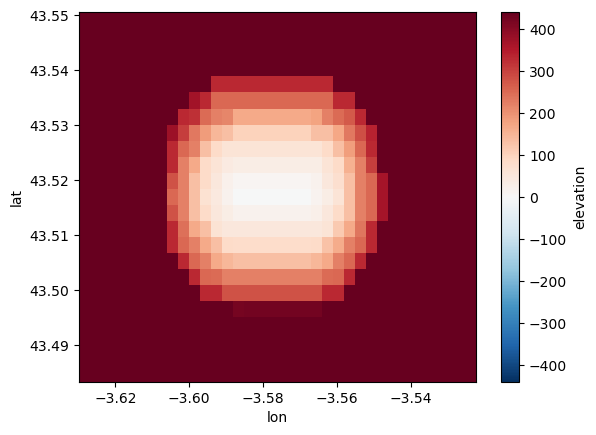

In [2]:
bathy.elevation.plot()

In [3]:
from bluemath_tk.wrappers._utils_wrappers import write_array_in_file
from bluemath_tk.wrappers.swan.swan_wrapper import SwanModelWrapper


class CustomSwanWrapper(SwanModelWrapper):
    """
    Custom SWAN wrapper that inherits from SwanModelWrapper.
    """

    def build_case(self, case_dir: str, case_context: dict) -> None:
        write_array_in_file(case_context.get("bathymetry"), f"{case_dir}/depth.dat")

In [4]:
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

fixed_parameters = generate_grid_parameters(bathy_data=bathy)
fixed_parameters["bathymetry"] = bathy.elevation.values
fixed_parameters

{'xpc': -3.6283266666666667,
 'ypc': 43.48486065217392,
 'alpc': 0,
 'xlenc': 0.10453333333333337,
 'ylenc': 0.0642686956521672,
 'mxc': 35,
 'myc': 22,
 'xpinp': -3.6283266666666667,
 'ypinp': 43.48486065217392,
 'alpinp': 0,
 'mxinp': 35,
 'myinp': 22,
 'dxinp': 0.002986666666666693,
 'dyinp': 0.0029213043478293343,
 'bathymetry': array([[440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      ],
        [440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 440.      , 440.      , 440.      , 440.      ,
         440.      , 44

In [5]:
metamodel_parameters = {
    "hs": [1.0],
    "per": [10.0],
    "dir": [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0],
    "dd": [10.0],
}
metamodel_parameters

{'hs': [1.0],
 'per': [10.0],
 'dir': [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0],
 'dd': [10.0]}

In [7]:
swan_wrapper = CustomSwanWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir="CASES",
)
swan_wrapper.build_cases(mode="all_combinations")

2025-10-01 08:47:12,320 - CustomSwanWrapper - WARNING - Parameter hs is not in the default_parameters
2025-10-01 08:47:12,321 - CustomSwanWrapper - WARNING - Parameter per is not in the default_parameters
2025-10-01 08:47:12,321 - CustomSwanWrapper - WARNING - Parameter dir is not in the default_parameters
2025-10-01 08:47:12,322 - CustomSwanWrapper - WARNING - Parameter dd is not in the default_parameters


In [8]:
swan_wrapper.run_cases_in_background(launcher="docker_serial")

In [9]:
swan_wrapper.monitor_cases()

,Case,Status
0,0000,100 %
1,0001,100 %
2,0002,100 %
3,0003,100 %
4,0004,100 %
5,0005,100 %
6,0006,100 %
7,0007,100 %


In [10]:
postprocessed_cases = swan_wrapper.postprocess_cases()
postprocessed_cases

<xarray.Dataset> Size: 80kB
Dimensions:   (case_num: 8, Yp: 23, Xp: 36)
Coordinates:
  * Xp        (Xp) float32 144B -3.628 -3.625 -3.622 ... -3.53 -3.527 -3.524
  * Yp        (Yp) float32 92B 43.48 43.49 43.49 43.49 ... 43.54 43.55 43.55
  * case_num  (case_num) int64 64B 0 1 2 3 4 5 6 7
Data variables:
    Hsig      (case_num, Yp, Xp) float32 26kB 1.002 1.001 0.9996 ... 1.003 1.003
    Tm02      (case_num, Yp, Xp) float32 26kB 7.632 7.632 7.63 ... 7.631 7.632
    Dir       (case_num, Yp, Xp) float32 26kB 0.2334 0.1533 ... 314.8 314.7

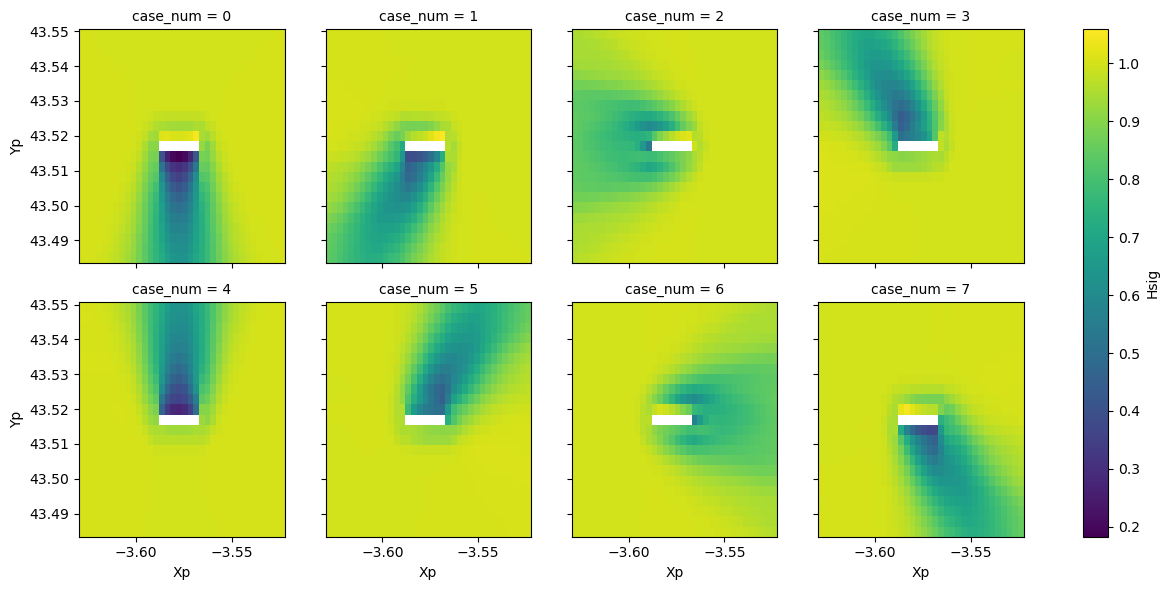

In [11]:
postprocessed_cases.Hsig.plot(col="case_num", col_wrap=4)